In [1]:
# Import the core data analysis libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set our visual style for later
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv('KaggleV2-May-2016.csv')

# Display the first 5 rows and the column data types
display(df.head())
print("\n--- Initial Data Types ---")
df.info()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No



--- Initial Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


## First Cleaning Pass

In [2]:
# 1. Fix typos in the column names
df.rename(columns={'Hipertension': 'Hypertension',
                   'Handcap': 'Handicap',
                   'SMS_received': 'SMSReceived',
                   'No-show': 'NoShow'}, inplace=True)
print("1. Columns renamed.")

# 2. Drop the impossible negative Age value
initial_rows = df.shape[0]
df = df[df['Age'] >= 0]
dropped_rows = initial_rows - df.shape[0]
print(f"2. Dropped {dropped_rows} row(s) with negative age.")

# 3. Convert Dates to proper Datetime objects
# We extract just the date part, then convert it to a datetime format
df['ScheduledDay'] = pd.to_datetime(pd.to_datetime(df['ScheduledDay']).dt.date)
df['AppointmentDay'] = pd.to_datetime(pd.to_datetime(df['AppointmentDay']).dt.date)
print("3. Dates converted to proper datetime format.")

# Check our work
print("\n--- Cleaned Data Types ---")
print(df[['ScheduledDay', 'AppointmentDay', 'Age']].dtypes)

1. Columns renamed.
2. Dropped 1 row(s) with negative age.
3. Dates converted to proper datetime format.

--- Cleaned Data Types ---
ScheduledDay      datetime64[ns]
AppointmentDay    datetime64[ns]
Age                        int64
dtype: object


## Feature Engineering (Creating "Wait Time")

In [3]:
# 1. Calculate the 'WaitTimeDays'
# We subtract the ScheduledDay from the AppointmentDay and extract just the number of days
df['WaitTimeDays'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days


# Let's check the summary of our new column
print("--- Wait Time Summary ---")
display(df['WaitTimeDays'].describe())


# 2. Identify Anomalies (Negative Wait Times)
# A patient cannot have an appointment BEFORE they schedule it. 
# Let's see if there are any data entry errors where this happened.
negative_wait = df[df['WaitTimeDays'] < 0]
print(f"\nRows with negative wait times (errors): {negative_wait.shape[0]}")


# 3. Clean the Anomalies
# We will keep only the rows where WaitTimeDays is 0 or greater
initial_rows = df.shape[0]
df = df[df['WaitTimeDays'] >= 0]
print(f"Dropped {initial_rows - df.shape[0]} rows with negative wait times.")


# 4. Extract Day of the Week
# Does the day of the week affect no-shows? Let's find out by creating a new column.
# Monday = 0, Sunday = 6. We will map these to actual names for easier reading.
day_mapping = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
df['AppointmentDayOfWeek'] = df['AppointmentDay'].dt.dayofweek.map(day_mapping)


print("\n--- New Features Created ---")
display(df[['ScheduledDay', 'AppointmentDay', 'WaitTimeDays', 'AppointmentDayOfWeek', 'NoShow']].head())

--- Wait Time Summary ---


count    110526.000000
mean         10.183794
std          15.255034
min          -6.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: WaitTimeDays, dtype: float64


Rows with negative wait times (errors): 5
Dropped 5 rows with negative wait times.

--- New Features Created ---


,ScheduledDay,AppointmentDay,WaitTimeDays,AppointmentDayOfWeek,NoShow
0,2016-04-29,2016-04-29,0,Friday,No
1,2016-04-29,2016-04-29,0,Friday,No
2,2016-04-29,2016-04-29,0,Friday,No
3,2016-04-29,2016-04-29,0,Friday,No
4,2016-04-29,2016-04-29,0,Friday,No


## Visualizing Trends

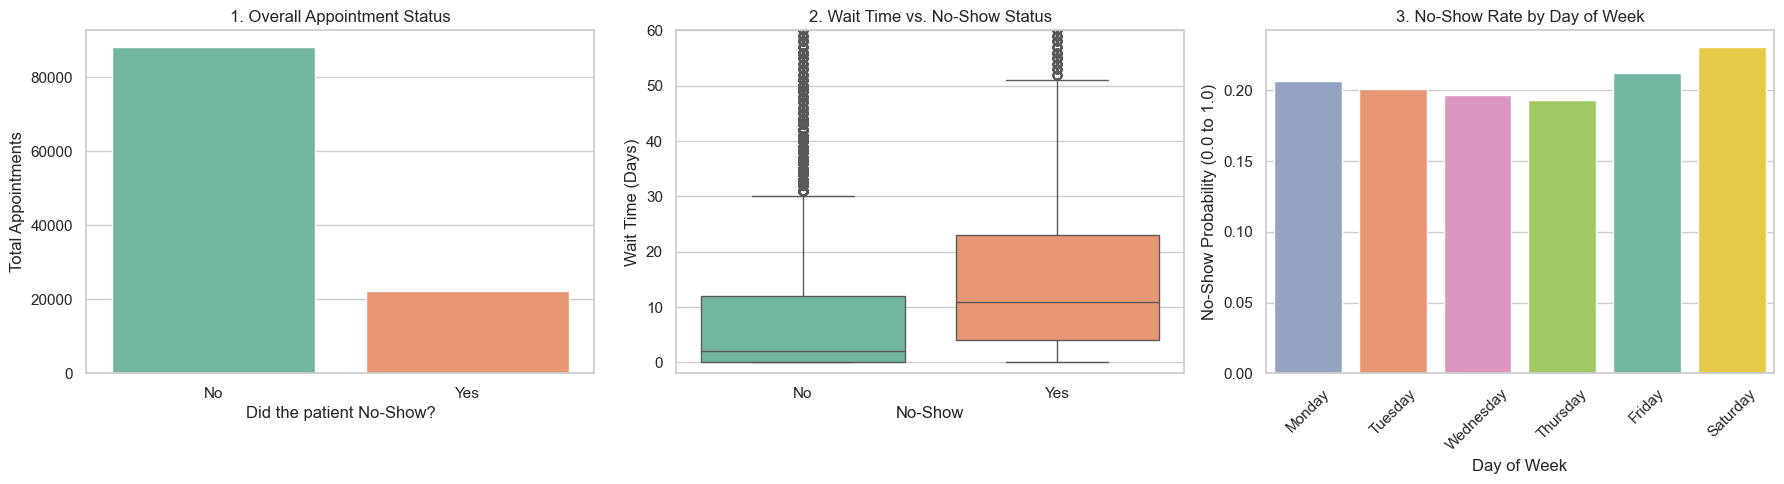

In [5]:
# Create a figure canvas with 3 subplots (1 row, 3 columns)
plt.figure(figsize=(18, 5))


# --- Plot 1: Overall No-Show Count ---
plt.subplot(1, 3, 1) 
# FIX: Added hue='NoShow' and legend=False
sns.countplot(x='NoShow', hue='NoShow', data=df, palette='Set2', legend=False)
plt.title('1. Overall Appointment Status')
plt.xlabel('Did the patient No-Show?')
plt.ylabel('Total Appointments')


# --- Plot 2: Impact of Wait Time on No-Shows ---
plt.subplot(1, 3, 2)
# FIX: Added hue='NoShow' and legend=False
sns.boxplot(x='NoShow', y='WaitTimeDays', hue='NoShow', data=df, palette='Set2', legend=False)
plt.title('2. Wait Time vs. No-Show Status')
plt.xlabel('No-Show')
plt.ylabel('Wait Time (Days)')
plt.ylim(-2, 60) 


# --- Plot 3: Day of the Week Trends ---
plt.subplot(1, 3, 3)
df['NoShow_Numeric'] = df['NoShow'].apply(lambda x: 1 if x == 'Yes' else 0)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

# FIX: Added hue='AppointmentDayOfWeek' and legend=False
sns.barplot(
    x='AppointmentDayOfWeek', 
    y='NoShow_Numeric', 
    hue='AppointmentDayOfWeek', 
    data=df, 
    order=day_order, 
    palette='Set2', 
    errorbar=None, 
    legend=False
)
plt.title('3. No-Show Rate by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('No-Show Probability (0.0 to 1.0)')
plt.xticks(rotation=45) 


plt.tight_layout() 
plt.show()

# Drop the temporary numeric column
df.drop(columns=['NoShow_Numeric'], inplace=True)

## Data Preprocessing

In [6]:
# Import machine learning tools from scikit-learn
from sklearn.model_selection import train_test_split

# 1. Encoding Text into Numbers
# Create a numerical Target column: 'Yes' (No-show) becomes 1, 'No' (Showed up) becomes 0
df['Target'] = df['NoShow'].map({'Yes': 1, 'No': 0})

# Convert Gender: 'F' becomes 0, 'M' becomes 1
df['Gender_Num'] = df['Gender'].map({'F': 0, 'M': 1})

# 2. Select the Features (X) and the Target (y)
# These are the clues the model will use to make its prediction
features = [
    'Age', 'Scholarship', 'Hypertension', 'Diabetes', 
    'Alcoholism', 'Handicap', 'SMSReceived', 'WaitTimeDays', 'Gender_Num'
]


X = df[features] # The clues
y = df['Target'] # The answer key

# 3. Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape[0]} patients")
print(f"Testing data size: {X_test.shape[0]} patients")
print("\nPreprocessing complete. Ready for modeling!")

Training data size: 88416 patients
Testing data size: 22105 patients

Preprocessing complete. Ready for modeling!


## Training the Random Forest Model

In [7]:
# Import the Random Forest algorithm and evaluation metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Initialize the Model (Create the 'Board of Directors' with 100 trees)
# random_state=42 ensures you get the exact same results every time you run it
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

print("Training the Random Forest model... (This might take a few seconds)\n")

# 2. Train the Model (Let it learn the patterns in the 80% training data)
rf_model.fit(X_train, y_train)


# 3. Make Predictions (Ask it to guess the answers for the 20% hidden test data)
predictions = rf_model.predict(X_test)


# 4. Evaluate the Results
accuracy = accuracy_score(y_test, predictions)
print(f"--- Model Performance ---")
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, predictions, target_names=['Showed Up (0)', 'No-Show (1)']))

Training the Random Forest model... (This might take a few seconds)

--- Model Performance ---
Overall Accuracy: 76.69%

Classification Report:
               precision    recall  f1-score   support

Showed Up (0)       0.82      0.91      0.86     17621
  No-Show (1)       0.36      0.19      0.25      4484

     accuracy                           0.77     22105
    macro avg       0.59      0.55      0.56     22105
 weighted avg       0.72      0.77      0.74     22105



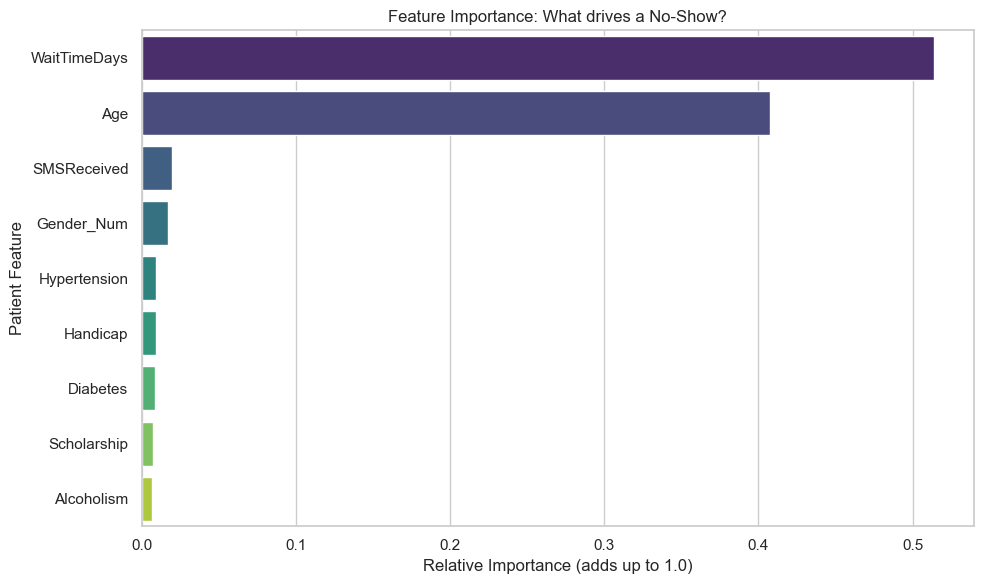

In [8]:
# 1. Extract the importance scores from our trained Random Forest model
importances = rf_model.feature_importances_

# 2. Package the scores into a clean Pandas DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

# 3. Sort them from most important to least important
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 4. Plot the results!
plt.figure(figsize=(10, 6))
# Using hue and legend=False to prevent FutureWarnings
sns.barplot(
    x='Importance', 
    y='Feature', 
    hue='Feature',
    data=feature_importance_df, 
    palette='viridis',
    legend=False
)

plt.title('Feature Importance: What drives a No-Show?')
plt.xlabel('Relative Importance (adds up to 1.0)')
plt.ylabel('Patient Feature')
plt.tight_layout()
plt.show()

## Exporting Trained Model

In [9]:
import joblib

# Saving the trained Random Forest model to a file
joblib.dump(rf_model, 'healthcare_rf_model.pkl')

print("Model successfully saved as 'healthcare_rf_model.pkl'!")

Model successfully saved as 'healthcare_rf_model.pkl'!
